# EDA — Metropolitano Troncal (línea exclusiva)

**Dataset crudo:** `data_processed/raw/troncal_hora.parquet`
**Origen:** hoja `COSAC - TRONCAL` del Excel ATU
**Periodo:** 2025 · **Grano:** estación × fecha × hora
**Guía de estructura:** `deliveries/week07/code/eda/eda_transmilenio.ipynb`

**Variables crudas:**

| Bloque | Columnas |
|--------|----------|
| Demanda | `validaciones` |
| Estación | `estacion` |
| Temporal | `fecha`, `hora` |

**Qué es el troncal:** buses del Metropolitano en la **pista exclusiva** (estaciones cerradas).


In [34]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RAIZ = Path.cwd().resolve().parents[1]
RAW = RAIZ / "data_processed" / "raw"
CLEAN = RAIZ / "data_processed" / "clean"
FIGS = RAIZ / "docs" / "images"
CLEAN.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

ANIO = 2025
UMBRAL_COBERTURA = 90
DIAS = ["LUN", "MAR", "MIÉ", "JUE", "VIE", "SÁB", "DOM"]
ORDEN_DIAS = DIAS

FERIADOS_PERU = {
    "2025-01-01": "Anio Nuevo", "2025-04-17": "Jueves Santo", "2025-04-18": "Viernes Santo",
    "2025-05-01": "Dia del Trabajo", "2025-06-29": "San Pedro y San Pablo",
    "2025-07-29": "Fiestas Patrias", "2025-08-30": "Santa Rosa de Lima",
    "2025-10-08": "Combate de Angamos", "2025-11-01": "Todos los Santos",
    "2025-12-08": "Inmaculada Concepcion", "2025-12-25": "Navidad",
}

MAPA_SENTIDO = {
    "NS": ("NS", "N->S"), "SN": ("NS", "S->N"),
    "NORTE-SUR": ("NS", "N->S"), "SUR-NORTE": ("NS", "S->N"),
    "OE": ("EO", "E->O"), "EO": ("EO", "O->E"),
    "OESTE-ESTE": ("EO", "E->O"), "ESTE-OESTE": ("EO", "O->E"),
    "IDA": ("NS", "N->S"), "VUELTA": ("NS", "S->N"),
    "N->S": ("NS", "N->S"), "S->N": ("NS", "S->N"),
    "E->O": ("EO", "E->O"), "O->E": ("EO", "O->E"),
    "N-S": ("NS", "N->S"), "S-N": ("NS", "S->N"),
}

COLOR = "#1f4e79"
SISTEMA = "troncal"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": True,
})
sns.set_style("whitegrid")


def guardar_fig(nombre: str) -> None:
    destino = FIGS / nombre
    plt.savefig(destino, bbox_inches="tight")
    plt.show()  # inline en la celda + archivo en docs/images
    plt.close()
    print(f"  [figura] {destino.relative_to(RAIZ)}")


def anadir_calendario(df: pd.DataFrame) -> pd.DataFrame:
    f = pd.to_datetime(df["fecha"], errors="coerce")
    out = df.copy()
    out["fecha"] = f.dt.normalize()
    out["anio"] = f.dt.year.astype("Int16")
    out["mes"] = f.dt.month.astype("Int8")
    dow = f.dt.dayofweek
    out["dia_semana"] = [DIAS[int(i)] if pd.notna(i) else None for i in dow]
    out["tipo_dia"] = np.select(
        [dow.isna(), dow <= 4, dow == 5, dow == 6],
        [None, "LAB", "SAB", "DOM"], default=None,
    )
    out["semana_iso"] = f.dt.isocalendar().week.astype("Int16")
    clave = out["fecha"].dt.strftime("%Y-%m-%d")
    out["feriado"] = clave.map(FERIADOS_PERU)
    out["es_feriado"] = out["feriado"].notna()
    return out


def ids_texto(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = (out[c].astype("string").str.replace(r"\.0$", "", regex=True).str.strip())
    return out


def normalizar_sentido(df: pd.DataFrame, col: str = "sentido") -> pd.DataFrame:
    out = df.copy()
    bruto = out[col].astype("string").str.strip().str.upper()
    par = bruto.map(MAPA_SENTIDO)
    out["sentido_norm"] = par.map(lambda t: t[1] if isinstance(t, tuple) else None)
    out["eje"] = par.map(lambda t: t[0] if isinstance(t, tuple) else None)
    out["sentido_crudo"] = bruto
    return out


def marcar_franja(hora: pd.Series) -> pd.Series:
    return pd.cut(
        hora.astype(int),
        bins=[-1, 5, 9, 15, 20, 24],
        labels=["madrugada", "pico_am", "valle", "pico_pm", "noche"],
    )


def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - k * iqr), float(q3 + k * iqr), float(q1), float(q3), float(iqr)


print(f"Sistema: {SISTEMA}")
print(f"RAW  : {RAW}")
print(f"CLEAN: {CLEAN}")


Sistema: troncal
RAW  : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/raw
CLEAN: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data_processed/clean


## 1. Carga del dataset crudo


In [35]:
ruta = RAW / "troncal_hora.parquet"
if not ruta.exists():
    raise FileNotFoundError(f"Falta {ruta}. Ejecuta prepare_parquet.py --anio {ANIO}")
df = pd.read_parquet(ruta)
print(f"Filas: {len(df):,} | Columnas: {list(df.columns)}")
df.head()


Filas: 398,928 | Columnas: ['fecha', 'estacion', 'hora', 'validaciones']


,fecha,estacion,hora,validaciones
0,2025-01-01,2 de Mayo,0,0
1,2025-01-01,2 de Mayo,1,0
2,2025-01-01,2 de Mayo,2,0
3,2025-01-01,2 de Mayo,3,0
4,2025-01-01,2 de Mayo,4,6


## 2. Inspección inicial


In [36]:
info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_%": (100 * df.isna().mean()).round(2),
    "unicos": df.nunique(dropna=False),
})
print(info.to_string())
print(f"\nRango fechas: {df['fecha'].min()} -> {df['fecha'].max()}")
df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T


                       dtype  nulos  nulos_%  unicos
fecha         datetime64[us]      0      0.0     365
estacion                 str      0      0.0      46
hora                   int64      0      0.0      24
validaciones           int64      0      0.0    5307

Rango fechas: 2025-01-01 00:00:00 -> 2025-12-31 00:00:00


,count,mean,min,1%,5%,25%,50%,75%,95%,99%,max,std
fecha,398928,2025-07-02 23:53:35.353146,2025-01-01 00:00:00,2025-01-04 00:00:00,2025-01-19 00:00:00,2025-04-03 00:00:00,2025-07-04 00:00:00,2025-10-02 00:00:00,2025-12-13 00:00:00,2025-12-28 00:00:00,2025-12-31 00:00:00,NaN
hora,398928.0,11.5,0.0,0.0,1.0,5.75,11.5,17.25,22.0,23.0,23.0,6.922195
validaciones,398928.0,320.235797,0.0,0.0,0.0,13.0,119.0,330.0,1286.0,2937.0,17477.0,778.244356


## 3. Limpieza

### 3.1 Tipos, calendario e identificadores

Normalizamos `fecha`, forzamos `estacion` a texto y agregamos calendario (feriados
que el archivo **no** trae).


In [37]:
df_raw = df.copy()
df = anadir_calendario(df)
df = ids_texto(df, ["estacion"])
df["hora"] = pd.to_numeric(df["hora"], errors="coerce").astype("Int16")
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce")
print("estaciones:", df["estacion"].nunique(), "| feriados:", df.loc[df["es_feriado"], "feriado"].nunique())


estaciones: 46 | feriados: 11


### 3.2 Nulos, ceros, negativos y duplicados

Quitamos `validaciones` nulas/≤0 para el EDA de demanda positiva y reportamos el volumen.


In [38]:
antes = len(df)
nulos = int(df["validaciones"].isna().sum())
neg = int((df["validaciones"] < 0).sum())
ceros = int((df["validaciones"] == 0).sum())
df["era_celda_vacia"] = df["validaciones"].isna()
n_na = int(df["era_celda_vacia"].sum())
n_zero_escritos = int((df["validaciones"] == 0).sum())
df["validaciones"] = pd.to_numeric(df["validaciones"], errors="coerce").fillna(0)
df = df[df["validaciones"] >= 0].copy()  # conserva ceros; NA→0+flag
print(f"NA→0+flag: {n_na:,} | ceros escritos: {n_zero_escritos:,} | filas panel={len(df):,}")
clave = ["fecha", "estacion", "hora"]
dups = int(df.duplicated(subset=clave).sum())
if dups:
    df = df.drop_duplicates(subset=clave, keep="first")
print(f"antes={antes:,} nulos={nulos} neg={neg} ceros={ceros} dups={dups} despues={len(df):,}")


NA→0+flag: 0 | ceros escritos: 56,225 | filas panel=398,928
antes=398,928 nulos=0 neg=0 ceros=56225 dups=0 despues=398,928


### 3.3 Cobertura temporal por estación

Umbral `UMBRAL_COBERTURA`. Las no fiables se marcan; el archivo limpio conserva todas.


            estacion  dias_con_datos  dias_esperados  pct_cobertura  fiable
           Las Vegas             197             365           54.0   False
           2 de Mayo             365             365          100.0    True
         28 de Julio             365             365          100.0    True
        22 De Agosto             365             365          100.0    True
        Andrés Reyes             365             365          100.0    True
             Angamos             365             365          100.0    True
            Aramburu             365             365          100.0    True
     Andres Belaunde             365             365          100.0    True
           Benavides             365             365          100.0    True
             Bulevar             365             365          100.0    True
              Canadá             365             365          100.0    True
   Canaval y Moreyra             365             365          100.0    True
            

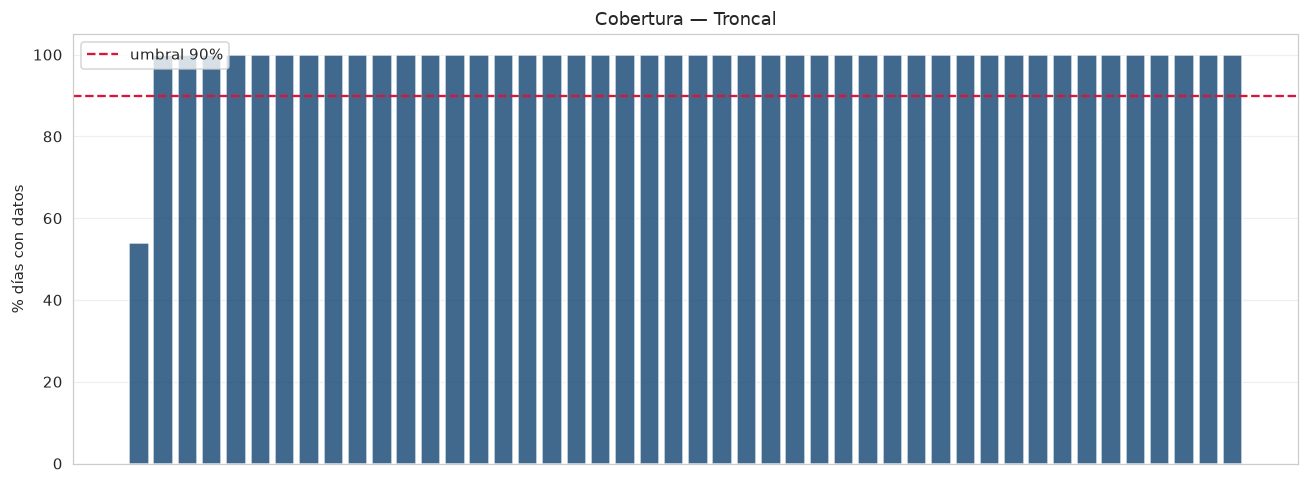

  [figura] docs/images/eda_troncal_cobertura.png
Filas en estaciones fiables: 394,200


In [39]:
dias_esperados = pd.date_range(f"{ANIO}-01-01", f"{ANIO}-12-31").normalize().nunique()
cob = (df.groupby("estacion")["fecha"].nunique().rename("dias_con_datos").reset_index())
cob["dias_esperados"] = dias_esperados
cob["pct_cobertura"] = (100 * cob["dias_con_datos"] / dias_esperados).round(1)
cob["fiable"] = cob["pct_cobertura"] >= UMBRAL_COBERTURA
print(cob.sort_values("pct_cobertura").to_string(index=False))
print(f"Fiables (>={UMBRAL_COBERTURA}%): {cob['fiable'].sum()}/{len(cob)}")

fig, ax = plt.subplots(figsize=(12, 4.5))
orden = cob.sort_values("pct_cobertura")
ax.bar(range(len(orden)), orden["pct_cobertura"], color=COLOR, alpha=0.85)
ax.axhline(UMBRAL_COBERTURA, color="crimson", ls="--", label=f"umbral {UMBRAL_COBERTURA}%")
ax.set_xticks([]); ax.set_ylabel("% días con datos"); ax.set_title("Cobertura — Troncal"); ax.legend()
guardar_fig("eda_troncal_cobertura.png")
estaciones_fiables = set(cob.loc[cob["fiable"], "estacion"].astype(str))
df_f = df[df["estacion"].astype(str).isin(estaciones_fiables)].copy()
print(f"Filas en estaciones fiables: {len(df_f):,}")


## 4. Feature engineering

`franja`, `log_val`, y `es_outlier_iqr` a nivel **estación-día** (más estable que la hora suelta).


In [40]:
df["franja"] = marcar_franja(df["hora"])
df["log_val"] = np.log1p(df["validaciones"])
diario = (df.groupby(["estacion", "fecha"], as_index=False)["validaciones"].sum()
          .rename(columns={"validaciones": "val_dia"}))
lo, hi, q1, q3, iqr = iqr_bounds(diario["val_dia"])
diario["es_outlier_iqr"] = (diario["val_dia"] < lo) | (diario["val_dia"] > hi)
df = df.merge(diario[["estacion", "fecha", "es_outlier_iqr"]], on=["estacion", "fecha"], how="left")
print(f"IQR estación-día: Q1={q1:,.0f} Q3={q3:,.0f} IQR={iqr:,.0f} límites=[{lo:,.0f},{hi:,.0f}]")
print(f"outlier días-estación: {diario['es_outlier_iqr'].mean():.2%} ({diario['es_outlier_iqr'].sum():,})")


IQR estación-día: Q1=2,192 Q3=9,544 IQR=7,352 límites=[-8,836,20,573]
outlier días-estación: 6.22% (1,034)


## 5. Outliers (IQR) — ¿borrarlos?

**Decisión: NO eliminarlos del dataset limpio.** En demanda de transporte los
valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR] suelen ser **picos reales**
(días de hub, eventos, punta acumulada). Borrar outliers sesgaría justo la cola
que un modelo de aforo/espera necesita aprender.

Sí los **marcamos** (`es_outlier_iqr`) para inspeccionarlos, estratificar el
análisis y, si hace falta, usar `log1p` en modelado.


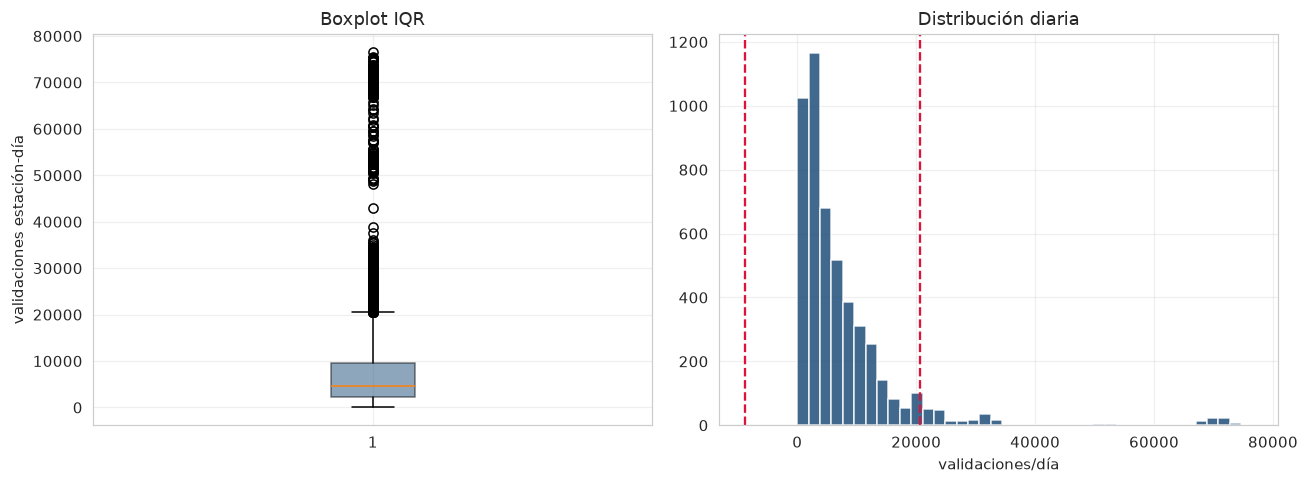

  [figura] docs/images/eda_troncal_outliers_iqr.png
estacion      fecha  val_dia
Naranjal 2025-04-30    76572
Naranjal 2025-10-31    75487
Naranjal 2025-12-22    75220
Naranjal 2025-12-12    75207
Naranjal 2025-12-19    75100
Naranjal 2025-11-28    74939
Naranjal 2025-12-10    74887
Naranjal 2025-12-05    74657
Naranjal 2025-10-28    74513
Naranjal 2025-12-18    73780


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].boxplot(diario["val_dia"], showfliers=True, patch_artist=True,
                boxprops=dict(facecolor=COLOR, alpha=0.5))
axes[0].set_ylabel("validaciones estación-día"); axes[0].set_title("Boxplot IQR")
muestra = diario.sample(min(5000, len(diario)), random_state=0)
axes[1].hist(muestra["val_dia"], bins=40, color=COLOR, alpha=0.85)
axes[1].axvline(lo, color="crimson", ls="--"); axes[1].axvline(hi, color="crimson", ls="--")
axes[1].set_title("Distribución diaria"); axes[1].set_xlabel("validaciones/día")
guardar_fig("eda_troncal_outliers_iqr.png")
print(diario[diario["es_outlier_iqr"]].nlargest(10, "val_dia")[["estacion","fecha","val_dia"]].to_string(index=False))


## 6. Análisis

### 6.1 Demanda global (univariado)


Total 2025: 127,751,026 | estaciones=46 | días=365


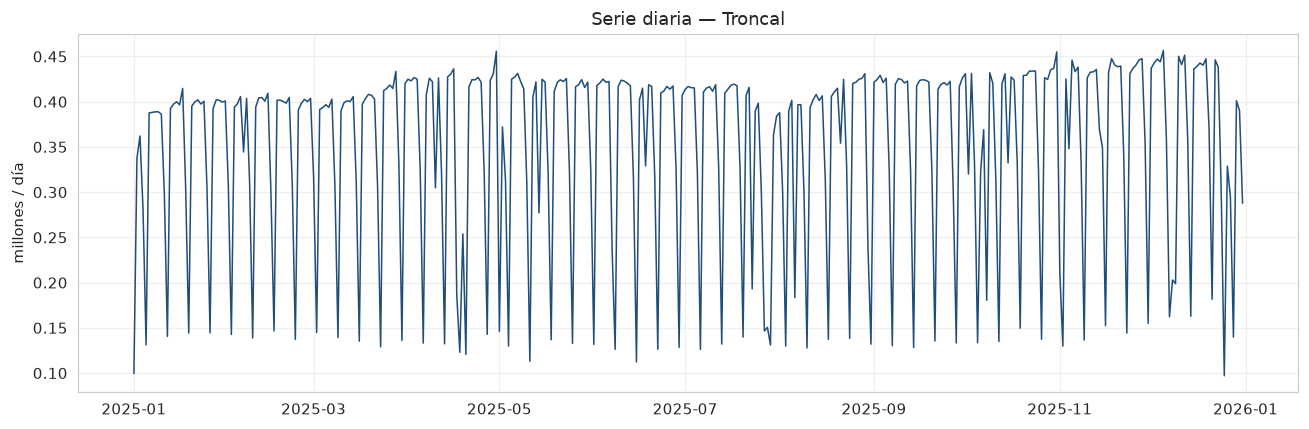

  [figura] docs/images/eda_troncal_serie_diaria.png


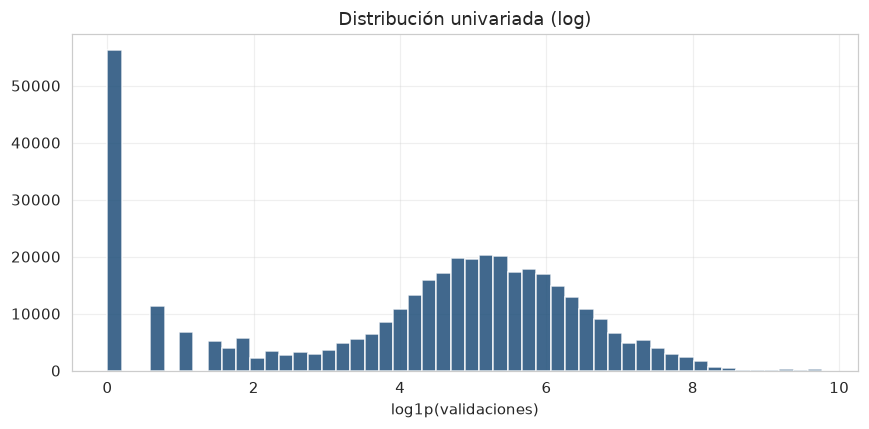

  [figura] docs/images/eda_troncal_hist_log.png


In [42]:
print(f"Total 2025: {df['validaciones'].sum():,.0f} | estaciones={df['estacion'].nunique()} | días={df['fecha'].nunique()}")
serie = df.groupby("fecha")["validaciones"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie.index, serie.values / 1e6, color=COLOR, lw=1)
ax.set_ylabel("millones / día"); ax.set_title("Serie diaria — Troncal")
guardar_fig("eda_troncal_serie_diaria.png")
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["log_val"], bins=50, color=COLOR, alpha=0.85)
ax.set_xlabel("log1p(validaciones)"); ax.set_title("Distribución univariada (log)")
guardar_fig("eda_troncal_hist_log.png")


### 6.2 Horario y día de semana (bivariado)


Top horas:
 hora
7     797.0
18    710.0
17    672.0
6     632.0
8     605.0
Punta 06-10h: 35.5% | 16-20h: 34.9%


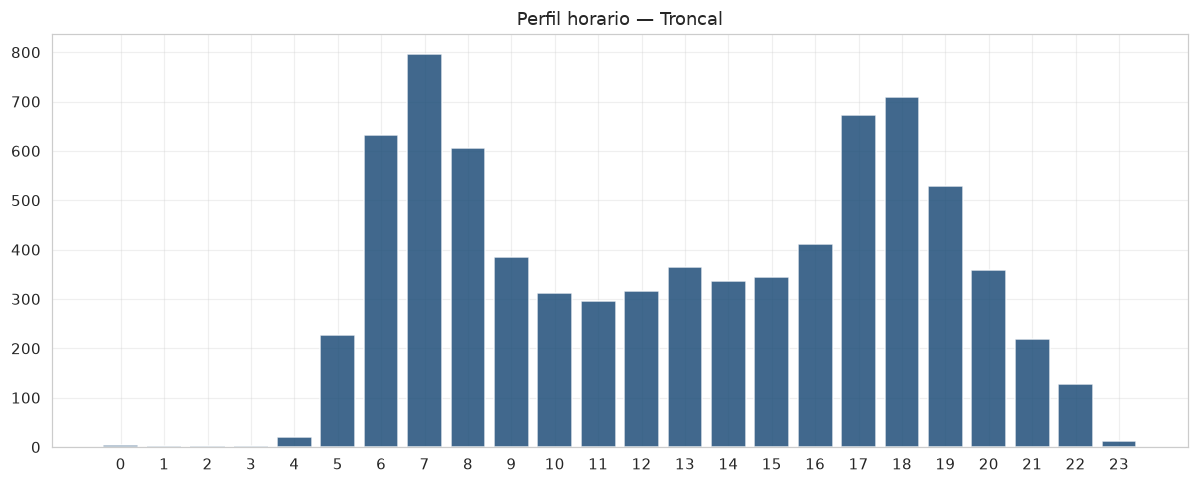

  [figura] docs/images/eda_troncal_perfil_horario.png
dia_semana
LUN    401094.0
MAR    405168.0
MIÉ    390169.0
JUE    393030.0
VIE    409414.0
SÁB    313195.0
DOM    137176.0


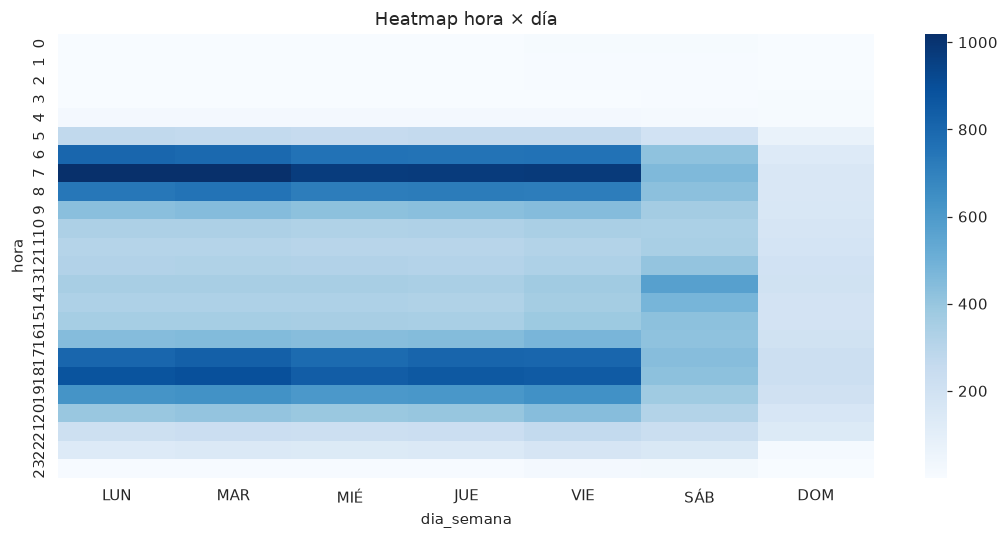

  [figura] docs/images/eda_troncal_heatmap_hora_dia.png


In [43]:
perfil = df.groupby("hora")["validaciones"].mean()
pct = 100 * perfil / perfil.sum()
print("Top horas:\n", perfil.nlargest(5).round(0).to_string())
print(f"Punta 06-10h: {pct[(pct.index>=6)&(pct.index<=10)].sum():.1f}% | 16-20h: {pct[(pct.index>=16)&(pct.index<=20)].sum():.1f}%")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(perfil.index, perfil.values, color=COLOR, alpha=0.85, width=0.8)
ax.set_xticks(range(0, 24)); ax.set_title("Perfil horario — Troncal")
guardar_fig("eda_troncal_perfil_horario.png")
por_dia = (df.groupby(["fecha","dia_semana"])["validaciones"].sum().groupby("dia_semana").mean().reindex(ORDEN_DIAS))
print(por_dia.round(0).to_string())
hm = df.pivot_table(index="hora", columns="dia_semana", values="validaciones", aggfunc="mean").reindex(columns=ORDEN_DIAS)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(hm, cmap="Blues", ax=ax); ax.set_title("Heatmap hora × día")
guardar_fig("eda_troncal_heatmap_hora_dia.png")


### 6.3 Ranking de estaciones


                   validaciones  dias  media_diaria  share_%
estacion                                                    
Naranjal               21380731   365       58577.0     17.0
Matellini               9828930   365       26929.0      8.0
Estacion Central        7457414   365       20431.0      6.0
Angamos                 6314609   365       17300.0      5.0
Javier Prado            5611774   365       15375.0      4.0
Chimpu Ocllo            4900693   365       13427.0      4.0
Tomas Valle             4821190   365       13209.0      4.0
Canaval y Moreyra       3972590   365       10884.0      3.0
Canadá                  3782960   365       10364.0      3.0
España                  3691165   365       10113.0      3.0
Benavides               3611636   365        9895.0      3.0
Izaguirre               3343835   365        9161.0      3.0
Ricardo Palma           3233476   365        8859.0      2.0
Jiron de la Unión       3178752   365        8709.0      2.0
Uni                     

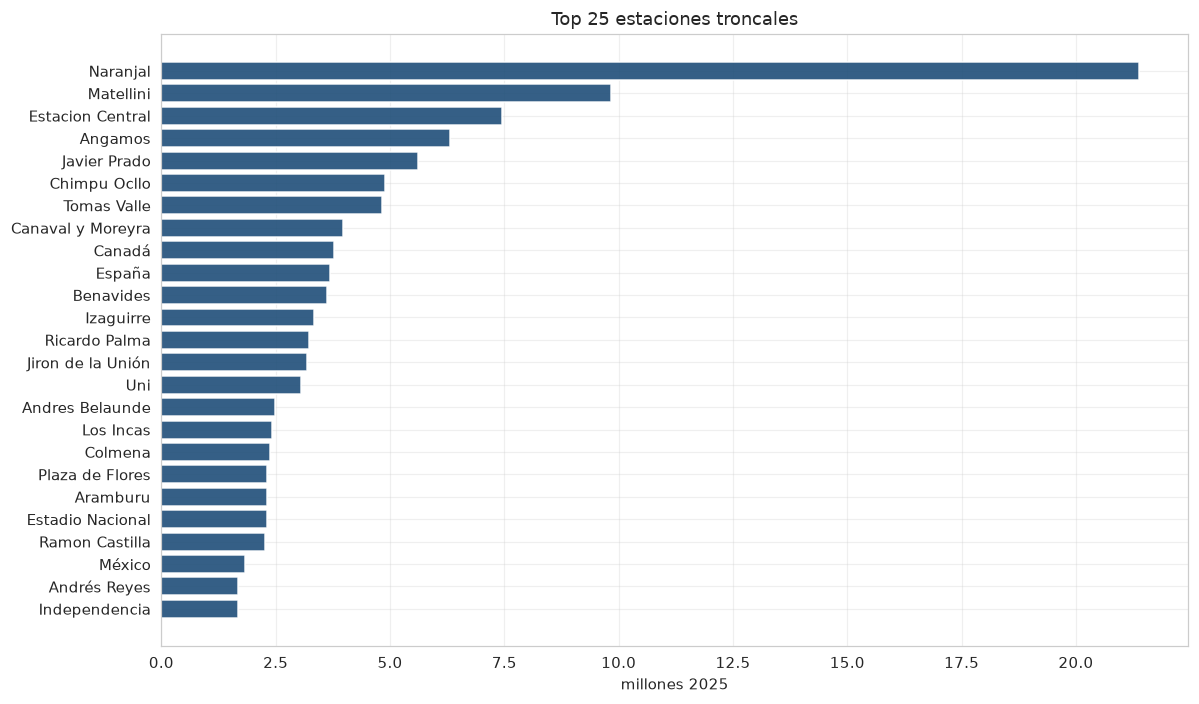

  [figura] docs/images/eda_troncal_ranking_estaciones.png


In [44]:
por_est = (df.groupby("estacion").agg(validaciones=("validaciones","sum"), dias=("fecha","nunique"))
           .sort_values("validaciones", ascending=False))
por_est["media_diaria"] = por_est["validaciones"] / por_est["dias"]
por_est["share_%"] = (100 * por_est["validaciones"] / por_est["validaciones"].sum()).round(1)
print(por_est.head(15).round(0).to_string())
print(f"Top 5: {por_est.head(5)['share_%'].sum():.1f}%")
fig, ax = plt.subplots(figsize=(11, 6.5))
top = por_est.sort_values("validaciones").tail(25)
ax.barh(top.index, top["validaciones"] / 1e6, color=COLOR, alpha=0.9)
ax.set_xlabel("millones 2025"); ax.set_title("Top 25 estaciones troncales")
guardar_fig("eda_troncal_ranking_estaciones.png")


### 6.4 Matriz de correlación (multivariado)

Sobre grano **estación × día** (no filas horarias crudas).


                 val_dia  hora_media_pond  n_horas    mes    dow  es_feriado_i
val_dia            1.000           -0.111      NaN  0.004 -0.148        -0.073
hora_media_pond   -0.111            1.000      NaN -0.023  0.081         0.036
n_horas              NaN              NaN      NaN    NaN    NaN           NaN
mes                0.004           -0.023      NaN  1.000 -0.008         0.038
dow               -0.148            0.081      NaN -0.008  1.000         0.008
es_feriado_i      -0.073            0.036      NaN  0.038  0.008         1.000


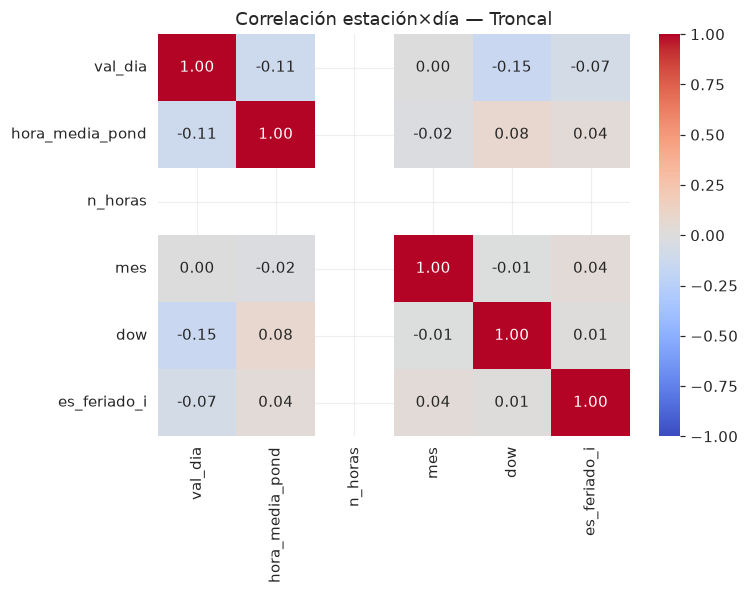

  [figura] docs/images/eda_troncal_correlacion.png


In [45]:
tmp = (df.groupby(["estacion", "fecha"], as_index=False)
       .apply(lambda g: pd.Series({
           "val_dia": g["validaciones"].sum(),
           "hora_media_pond": np.average(g["hora"].astype(float), weights=g["validaciones"]),
           "n_horas": g["hora"].nunique(),
       }), include_groups=False).reset_index(drop=True))
feat = (df.groupby(["estacion", "fecha", "dia_semana", "mes", "es_feriado"], as_index=False)
        .size().drop(columns="size"))
feat = feat.merge(tmp, on=["estacion", "fecha"])
feat["es_feriado_i"] = feat["es_feriado"].astype(int)
feat["dow"] = feat["dia_semana"].map({d: i for i, d in enumerate(DIAS)})
cols = ["val_dia", "hora_media_pond", "n_horas", "mes", "dow", "es_feriado_i"]
corr = feat[cols].corr()
print(corr.round(3).to_string())
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación estación×día — Troncal")
guardar_fig("eda_troncal_correlacion.png")


### Decisión missingness (panel para ML)

- **NA (celda vacía Excel)** → `validaciones = 0` + `era_celda_vacia = True` (cero estructural de reporte; **no** KNN).
- **Cero escrito** → se **conserva** (señal real de nula demanda).
- Plots de cola/IQR pueden filtrar `validaciones > 0` sin borrar el panel.
- Así el modelo de abordar/esperar/cambiar aprende también cuándo un paradero está vacío.


## Mapa de demanda (Folium)

Misma lógica que el EDA TransMilenio (week07): elige `nivel` = `dia` | `dow` | `hora`.

Puntos desde `data/fuentes/geo/`; trazado LineString/shp cuando existe.
Los NA del Excel ya están como **0 + `era_celda_vacia`** en el panel (no sesgamos borrando ceros).


In [46]:
import sys
import importlib
sys.path.insert(0, str(RAIZ / "code" / "scripts"))
import eda_geo_maps
importlib.reload(eda_geo_maps)
from eda_geo_maps import load_puntos, load_trazado_path, mapa_demanda, find_mapa_atu_corredor, find_mapa_atu_metro

GEO = RAIZ / "data" / "fuentes" / "geo"
FUENTES = RAIZ / "data" / "fuentes"
MAPS = RAIZ / "docs" / "maps"
MAPS.mkdir(parents=True, exist_ok=True)
print("GeoJSON en", GEO)
print("eda_geo_maps:", eda_geo_maps.__file__)
print(list(GEO.glob("*.geojson")))


GeoJSON en /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo
eda_geo_maps: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/code/scripts/eda_geo_maps.py
[PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_metro_l1.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazado_metro_l1.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_corredores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazados_corredores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_troncal.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/trazado_troncal.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/puntos_alimentadores.geojson'), PosixPath('/home/evssz/UTEC/6to/DPD/D

Mapa oficial ATU: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/data/fuentes/geo/mapas_metropolitano/RegularA/A-REGULAR.png


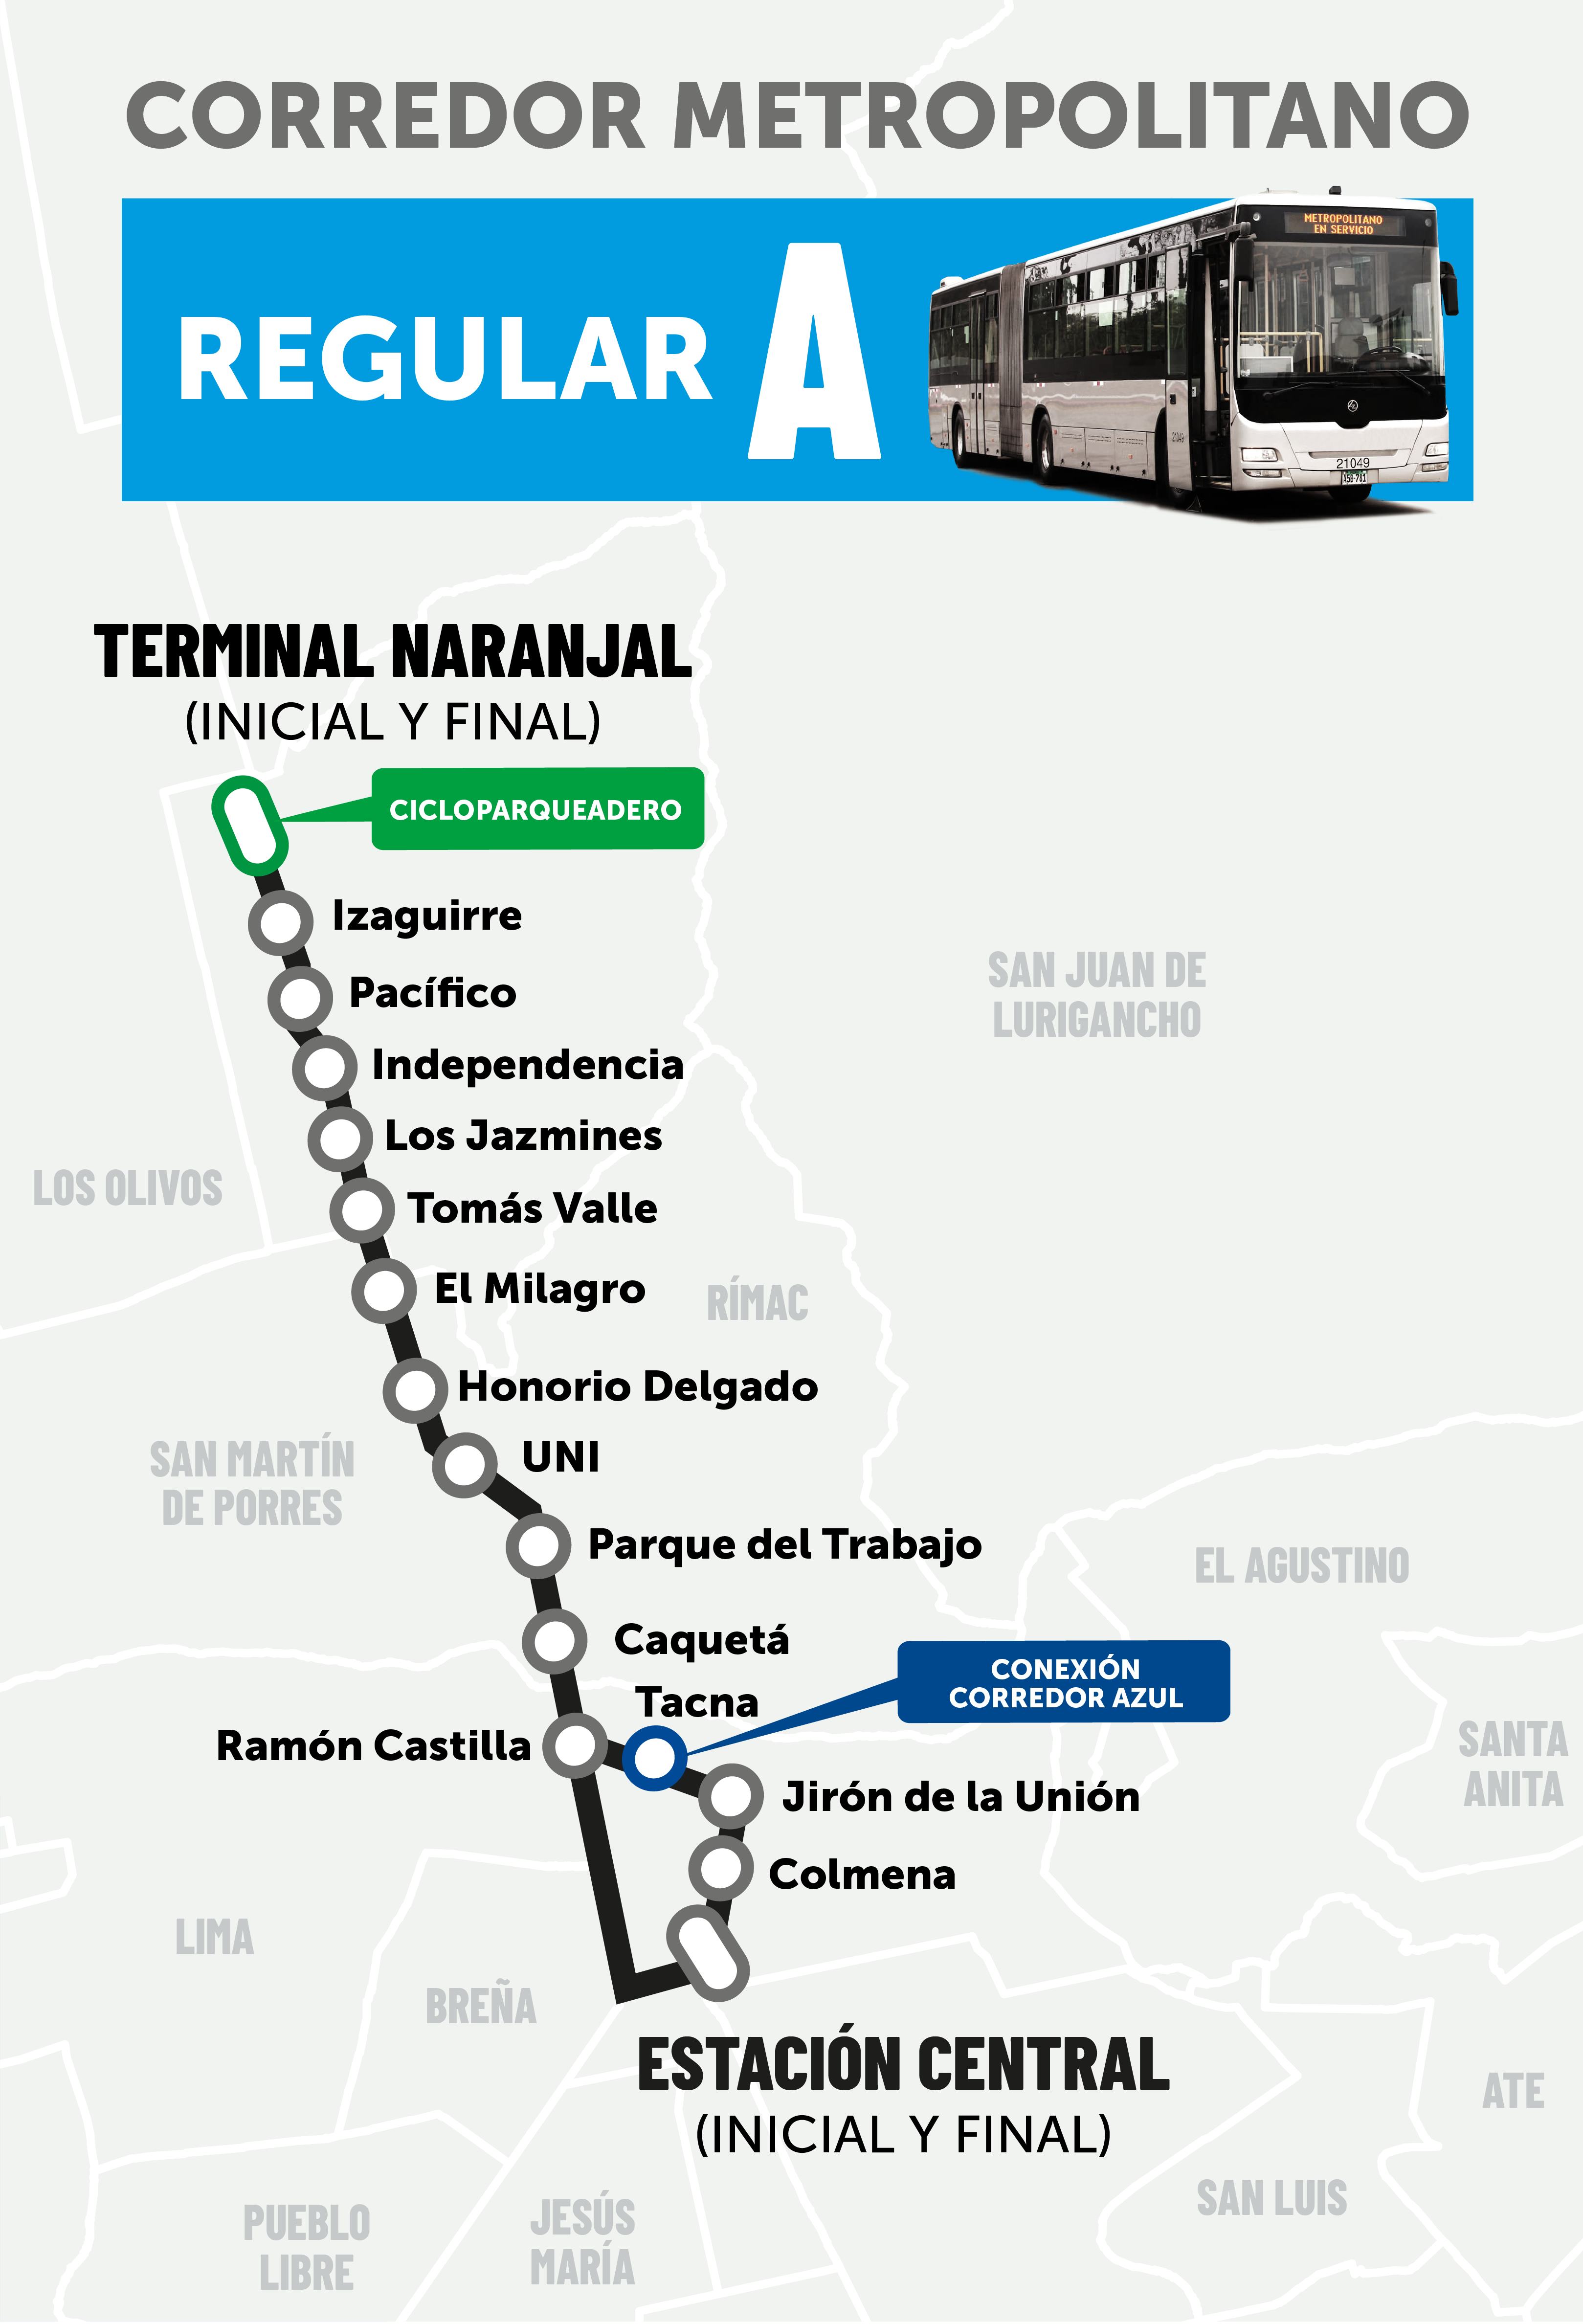

estaciones servicio RegularA : 12
Viendo total de todos los MAR del periodo: 56,832 filas, 21,068,752 validaciones
Unidades en mapa: 12 / 46 con demanda en la selección (26.1% geocodificadas)
  filtrado a unidades del trazado: 12
  [mapa] /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/docs/maps/mapa_metro_RegularA.html


In [47]:
# --- Mapa Folium Metropolitano (editar y re-ejecutar) ---
# Burbujas = validaciones por ESTACIÓN | Línea = trazado de UN SERVICIO ATU
# Tooltip de cada estación lista otros servicios que también pasan por ahí.
#
# Alternativas servicio_mapa (slugs portal ATU):
#   EX11-NS | EX13-NS | EX9-NS | Lechucero | RegularA | RegularB | RegularC | RegularD | SX-M | SXN-NS-M | X1-M | X10 | X12 | X3-N | X5 | X6 | X7 | X8
#
# Alternativas estacion_mapa (resaltar / zoom; None = todas del servicio):
#   "2 de Mayo", "22 De Agosto", "28 de Julio", "Andres Belaunde", "Andrés Reyes", "Angamos", "Aramburu", "Balta", "Benavides", "Bulevar", "Canadá", "Canaval y Moreyra", ...
#   (todas las del panel troncal en df["estacion"].unique())
#
# nivel: "dia" | "dow" | "hora"
# dia_sem: "LUN"|"MAR"|"MIE"|"JUE"|"VIE"|"SAB"|"DOM"

servicio_mapa = "RegularA"
estacion_mapa = None
nivel = "dow"
fecha = "2025-07-15"
dia_sem = "MAR"
hora = 8

from IPython.display import Image, display
from eda_geo_maps import (
    mapa_demanda, find_mapa_atu_metro, servicios_por_estacion,
)
import json

img = find_mapa_atu_metro(FUENTES, servicio_mapa)
if img is not None:
    print("Mapa oficial ATU:", img)
    display(Image(filename=str(img), width=700))
else:
    print("Sin imagen ATU para", servicio_mapa)

# puntos del servicio
fc = json.loads((GEO / "puntos_metropolitano_servicios.geojson").read_text(encoding="utf-8"))
rows = []
for f in fc["features"]:
    if str(f["properties"].get("servicio_slug")) != str(servicio_mapa):
        continue
    lon, lat = f["geometry"]["coordinates"][:2]
    rows.append({
        "unidad": str(f["properties"].get("estacion")),
        "lat": lat, "lon": lon,
        "label": str(f["properties"].get("estacion")),
        "otros": f["properties"].get("otros_servicios") or "",
    })
puntos_srv = pd.DataFrame(rows).drop_duplicates("unidad")
print("estaciones servicio", servicio_mapa, ":", len(puntos_srv))

tip = {r["unidad"]: ("Otros servicios: " + r["otros"]) if r["otros"] else "" for _, r in puntos_srv.iterrows()}
# también inventarios globales estación→servicios
tip.update({k: v for k, v in servicios_por_estacion(FUENTES).items() if k not in tip})

m = mapa_demanda(
    df, puntos_srv,
    unidad_col="estacion",
    trazado=GEO / "trazados_metropolitano_servicios.geojson",
    trazado_filter={"servicio_slug": str(servicio_mapa)},
    nivel=nivel, fecha=fecha, dia_sem=dia_sem, hora=hora,
    color_linea="#1f4e79",
    highlight_unidad=estacion_mapa,
    tooltip_extra=tip,
    unidades_keep=puntos_srv["unidad"].tolist() if len(puntos_srv) else None,
    save_html=MAPS / f"mapa_metro_{servicio_mapa}.html",
)
display(m)  # se renderiza inline (como week07)


### 6.5 Conclusiones

1. Doble punta mañana/tarde; ambas importan para modelar espera/aforo.
2. Cobertura ~99%; filtrar estaciones incompletas en promedios sensibles.
3. Outliers IQR se **conservan** (picos reales) y se marcan.
4. Variables clave: `estacion`, `hora`, `dia_semana`, `es_feriado`.
5. Salida: `data_processed/clean/troncal_hora.parquet`.


In [48]:
cols_out = ["fecha","anio","mes","dia_semana","tipo_dia","semana_iso","feriado","es_feriado",
            "estacion","hora","franja","validaciones","log_val","es_outlier_iqr","era_celda_vacia"]
out = df[cols_out].sort_values(["fecha","estacion","hora"])
destino = CLEAN / "troncal_hora.parquet"
out.to_parquet(destino, index=False, compression="snappy")
print(f"Guardado {destino.relative_to(RAIZ)} | {len(out):,} filas")
cob_out = cob.rename(columns={"estacion":"unidad"}).copy()
cob_out.insert(0, "sistema", "troncal")
cob_out.to_csv(CLEAN / "calidad_cobertura_troncal.csv", index=False)


Guardado data_processed/clean/troncal_hora.parquet | 398,928 filas
